# Calorie Expenditure Prediction — Kaggle Playground S5E5

**Final Result: Top 0.6% — 27th place out of 4,316 teams | RMSLE: 0.05852**

This notebook documents my full competition workflow for predicting calorie expenditure from exercise metrics. The approach evolved across several iterations — from a simple GBM baseline through Bayesian hyperparameter optimization to a final inverse-error weighted ensemble of three tuned gradient boosting models.

---

### Competition Overview
- **Dataset:** 750K+ exercise records with biometric features (age, height, weight, duration, heart rate, body temperature)
- **Target:** Calories burned
- **Metric:** Root Mean Squared Logarithmic Error (RMSLE)
- **Approach:** Weighted ensemble of HistGradientBoosting + LightGBM + XGBoost with Bayesian-tuned hyperparameters

## 1. Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import lightgbm as lgb
import xgboost as xgb_lib

In [ ]:
class CFG:
    train_path = "/kaggle/input/playground-series-s5e5/train.csv"
    test_path = "/kaggle/input/playground-series-s5e5/test.csv"
    target = "Calories"
    n_folds = 5
    seed = 42
    cv = KFold(n_splits=n_folds, random_state=seed, shuffle=True)

def rmsle(y_true, y_pred):
    """Root Mean Squared Logarithmic Error — competition metric."""
    return np.sqrt(mean_squared_log_error(y_true, np.maximum(y_pred, 0)))

## 2. Data Preprocessing

Features are standardized using `StandardScaler` fit on the training set only — the same scaler is applied to the test set to prevent data leakage. The single categorical feature (`Sex`) is one-hot encoded with `drop_first=True`.

In [3]:
df_train = pd.read_csv(CFG.train_path)
df_test = pd.read_csv(CFG.test_path)

print(f"Train shape: {df_train.shape} | Test shape: {df_test.shape}")
print(f"\nFeatures: {list(df_train.drop(columns=['id', CFG.target]).columns)}")
print(f"\nTarget stats:\n{df_train[CFG.target].describe()}")

Train shape: (750000, 9) | Test shape: (250000, 8)

Features: ['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

Target stats:
count    750000.000000
mean         88.282781
std          62.395349
min           1.000000
25%          34.000000
50%          77.000000
75%         136.000000
max         314.000000
Name: Calories, dtype: float64


In [4]:
numerical_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

# Fit scaler on training data only
scaler = StandardScaler()

X_raw = df_train.drop(columns=[CFG.target])
y = df_train[CFG.target]

X_scaled = pd.DataFrame(scaler.fit_transform(X_raw[numerical_cols]), columns=numerical_cols)
X_dummies = pd.get_dummies(X_raw['Sex'], drop_first=True, dtype=int)
X_train_full = pd.concat([X_scaled, X_dummies], axis=1)

# Apply same scaler to test set
X_test_scaled = pd.DataFrame(scaler.transform(df_test[numerical_cols]), columns=numerical_cols)
X_test_dummies = pd.get_dummies(df_test['Sex'], drop_first=True, dtype=int)
X_test = pd.concat([X_test_scaled, X_test_dummies], axis=1)

# Train/val split for iterative development
x_train, x_val, y_train, y_val = train_test_split(X_train_full, y, test_size=0.2, random_state=207)

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {X_test.shape}")

Train: (600000, 7) | Val: (150000, 7) | Test: (250000, 7)


## 3. Exploratory Data Analysis

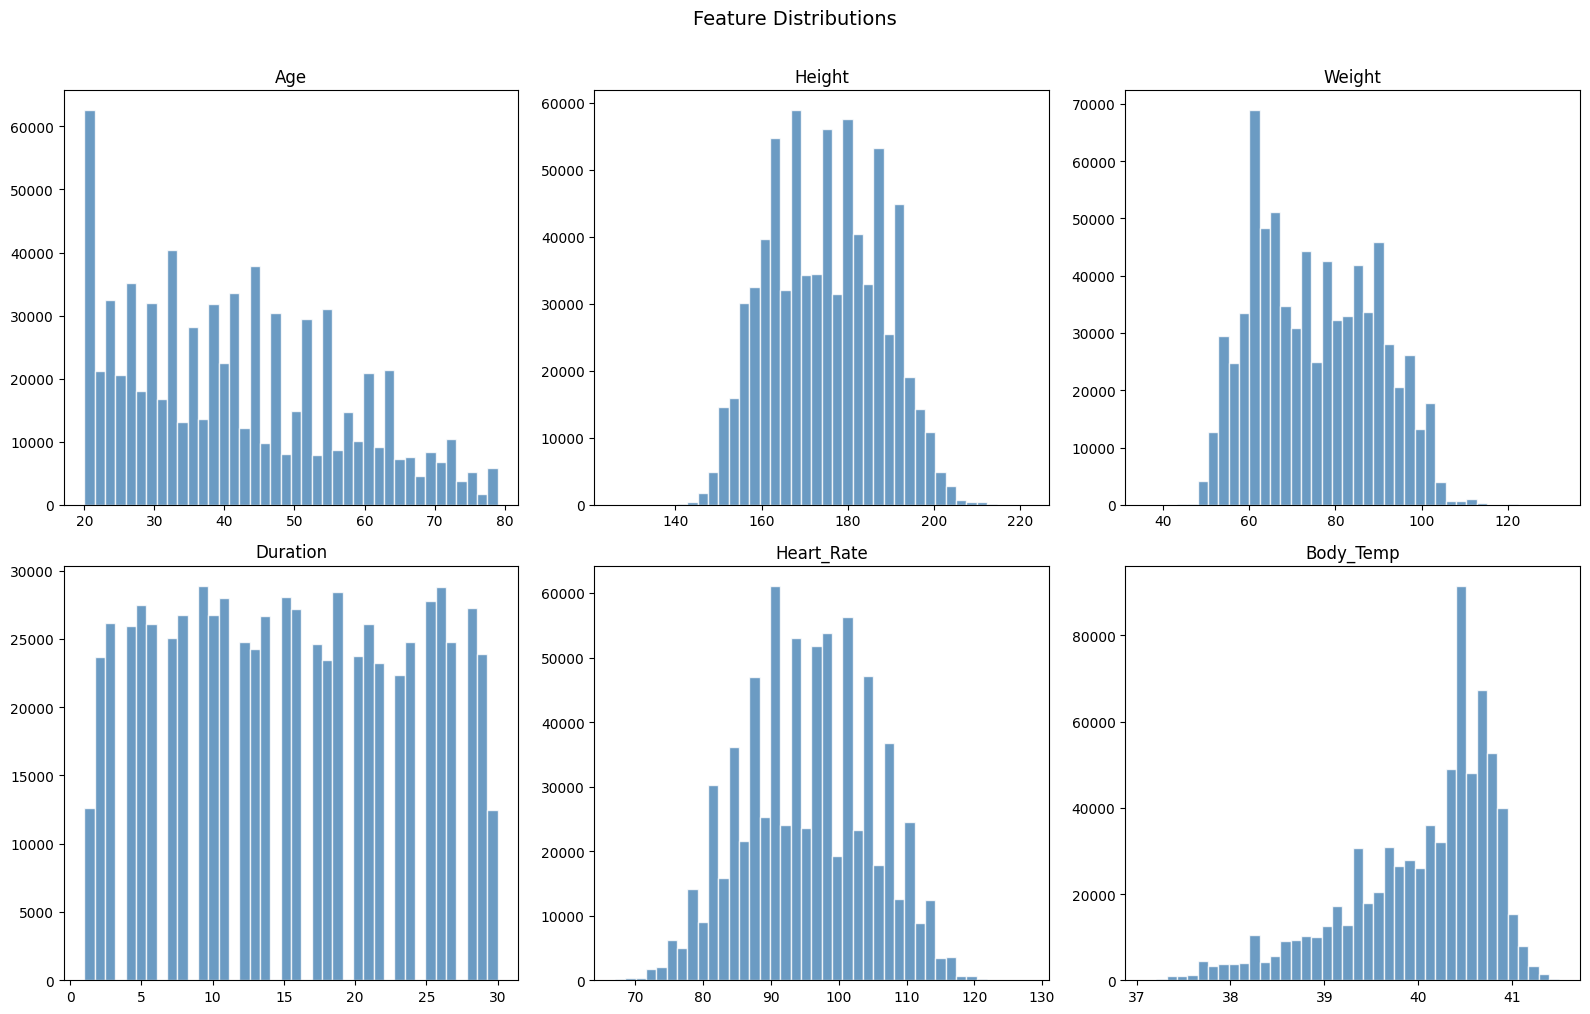

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df_train[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

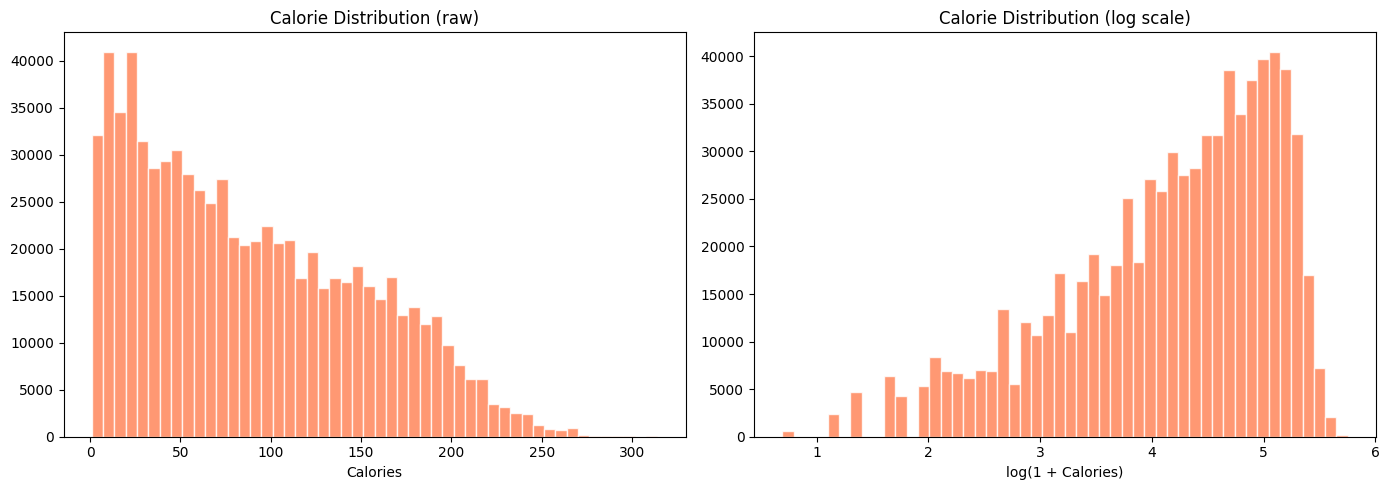

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df_train[CFG.target], bins=50, color='coral', edgecolor='white', alpha=0.8)
ax1.set_title('Calorie Distribution (raw)')
ax1.set_xlabel('Calories')

ax2.hist(np.log1p(df_train[CFG.target]), bins=50, color='coral', edgecolor='white', alpha=0.8)
ax2.set_title('Calorie Distribution (log scale)')
ax2.set_xlabel('log(1 + Calories)')

plt.tight_layout()
plt.show()

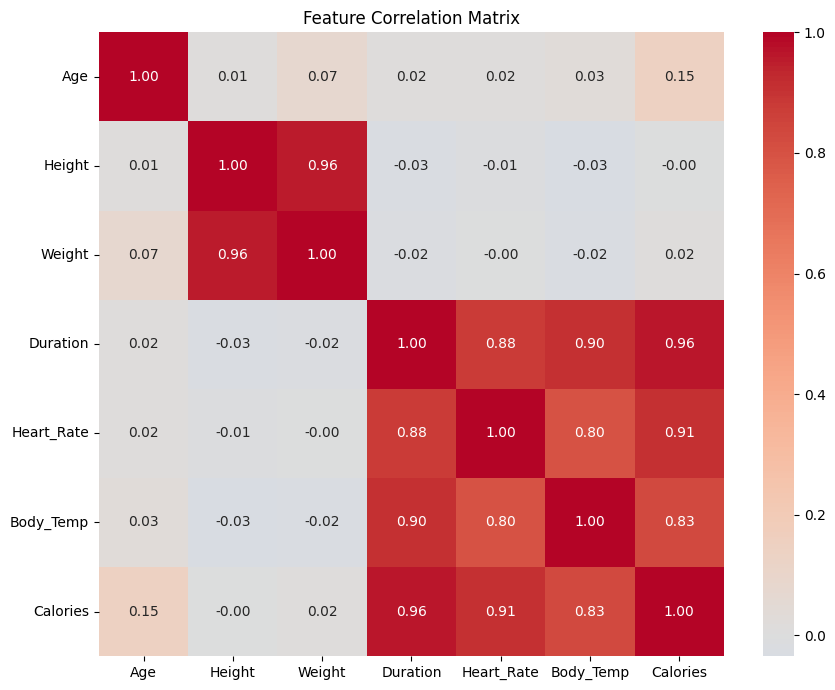

In [7]:
corr = df_train[numerical_cols + [CFG.target]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Baseline — GBM with Feature Selection

Starting with a simple GBM on the three most correlated features (Age, Heart Rate, Duration) to establish a baseline. No tuning, default-ish parameters.

**Result: RMSLE 0.0934**

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

baseline_features = ['Age', 'Heart_Rate', 'Duration']

gb_baseline = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=8,
    random_state=CFG.seed
)

gb_baseline.fit(x_train[baseline_features], y_train)
y_baseline = gb_baseline.predict(x_val[baseline_features])

baseline_rmsle = rmsle(y_val, y_baseline)
print(f'Baseline RMSLE (3 features): {baseline_rmsle:.5f}')

Baseline RMSLE (3 features): 0.09340


## 5. Bayesian Hyperparameter Optimization

Using Hyperopt with Tree-structured Parzen Estimator (TPE) to tune LightGBM and XGBoost hyperparameters. TPE is more sample-efficient than grid search — it builds a probabilistic model of the objective function and focuses evaluations on promising regions of the search space.

### 5.1 Bayesian HistGBM

In [ ]:
train_data_histgb = lgb.Dataset(x_train, label=y_train)

def histgb_objective(params):
    params = {
        'max_depth': int(params['max_depth']),
        'max_leaf_nodes': int(params['max_leaf_nodes']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'max_iter': int(params['max_iter']),
        'learning_rate': params['learning_rate'],
        'l2_regularization': params['l2_regularization'],
        'random_state': CFG.seed
    }
    model = HistGradientBoostingRegressor(**params)
    model.fit(x_train, y_train)
    y_pred = np.maximum(model.predict(x_val), 0)
    return {'loss': rmsle(y_val, y_pred), 'status': STATUS_OK}

histgb_space = {
    'learning_rate': hp.loguniform('learning_rate', np.log(0.005), np.log(0.1)),
    'max_depth': hp.quniform('max_depth', 5, 60, 1),
    'max_leaf_nodes': hp.quniform('max_leaf_nodes', 20, 400, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 10, 100, 1),
    'l2_regularization': hp.loguniform('l2_regularization', np.log(0.1), np.log(15.0)),
    'max_iter': hp.quniform('max_iter', 500, 5000, 100),
}

histgb_trials = Trials()
best_histgb = fmin(fn=histgb_objective, space=histgb_space, algo=tpe.suggest,
                   max_evals=100, trials=histgb_trials, rstate=np.random.default_rng(CFG.seed))

print("Best HistGB params:", best_histgb)

### 5.2 Bayesian LightGBM

In [ ]:
train_data = lgb.Dataset(x_train, label=y_train)

def lgbm_objective(params):
    params = {
        'max_depth': int(params['max_depth']),
        'num_leaves': int(params['num_leaves']),
        'min_child_samples': int(params['min_child_samples']),
        'learning_rate': params['learning_rate'],
        'reg_alpha': params['reg_alpha'],
        'reg_lambda': params['reg_lambda'],
        'objective': 'regression',
        'force_col_wise': True,
        'verbose': -1,
    }
    clf = lgb.train(params, train_data, num_boost_round=100)
    y_pred = np.maximum(clf.predict(x_val), 0)
    return {'loss': rmsle(y_val, y_pred), 'status': STATUS_OK}

lgbm_space = {
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'max_depth': hp.quniform('max_depth', 3, 12, 1),
    'num_leaves': hp.quniform('num_leaves', 10, 50, 1),
    'min_child_samples': hp.quniform('min_child_samples', 5, 50, 1),
    'reg_alpha': hp.uniform('reg_alpha', 0.0, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 0.0, 1.0),
}

lgbm_trials = Trials()
best_lgbm = fmin(fn=lgbm_objective, space=lgbm_space, algo=tpe.suggest,
                 max_evals=100, trials=lgbm_trials, rstate=np.random.default_rng(CFG.seed))

print("Best LightGBM params:", best_lgbm)

### 5.3 Bayesian XGBoost

In [ ]:
def xgb_objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': params['learning_rate'],
        'min_child_weight': params['min_child_weight'],
        'gamma': params['gamma'],
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'tree_method': 'hist',
        'objective': 'reg:squarederror',
    }
    model = XGBRegressor(early_stopping_rounds=50, **params)
    model.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose=False)
    y_pred = np.maximum(model.predict(x_val), 0)
    return {'loss': rmsle(y_val, y_pred), 'status': STATUS_OK}

xgb_space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'max_depth': hp.quniform('max_depth', 3, 12, 1),
    'min_child_weight': hp.uniform('min_child_weight', 1, 10),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
}

xgb_trials = Trials()
best_xgb = fmin(fn=xgb_objective, space=xgb_space, algo=tpe.suggest,
                max_evals=100, trials=xgb_trials, rstate=np.random.default_rng(CFG.seed))

print("Best XGBoost params:", best_xgb)

## 6. Final Ensemble

Three tuned models are combined using **inverse-error weighting** — each model's weight is proportional to `1 / RMSLE`, so better-performing models contribute more to the final prediction. Weights are normalized to sum to 1.

We also check error correlations between models: lower correlation means the models make different mistakes, which is what makes an ensemble effective.

### 6.1 Tuned Hyperparameters

Final parameters after Bayesian optimization:

In [15]:
histgb_params = {
    "l2_regularization": 10.412017522533768,
    "learning_rate": 0.011702680619474444,
    "max_depth": 59,
    "max_iter": 4454,
    "max_leaf_nodes": 385,
    "min_samples_leaf": 50,
    "random_state": CFG.seed
}

lightgbm_params = {
    'learning_rate': 0.2504313952762866,
    'max_depth': 7,
    'min_child_samples': 37,
    'num_leaves': 24,
    'reg_alpha': 0.657493833059281,
    'reg_lambda': 0.1127275558436528,
    'random_state': CFG.seed
}

xgboost_params = {
    'colsample_bylevel': 0.6028203489279623,
    'colsample_bytree': 0.8676330490237509,
    'gamma': 0.1892087632574542,
    'grow_policy': 'depthwise',
    'learning_rate': 0.04605392670095021,
    'max_depth': 11,
    'min_child_weight': 1.0367455960726761,
    'n_estimators': 175,
    'subsample': 0.8393137361414497,
    'random_state': CFG.seed
}

### 6.2 Train & Evaluate Individual Models

In [ ]:
histgb = HistGradientBoostingRegressor(**histgb_params)
lgbm = LGBMRegressor(**lightgbm_params)
xgb = XGBRegressor(**xgboost_params)

histgb.fit(x_train, y_train)
lgbm.fit(x_train, y_train)
xgb.fit(x_train, y_train)

histgb_pred = histgb.predict(x_val)
lgbm_pred = lgbm.predict(x_val)
xgb_pred = xgb.predict(x_val)

histgb_rmsle = rmsle(y_val, histgb_pred)
lgbm_rmsle = rmsle(y_val, lgbm_pred)
xgb_rmsle = rmsle(y_val, xgb_pred)

print("Individual Model RMSLE Scores:")
print(f"  HistGradientBoosting : {histgb_rmsle:.5f}")
print(f"  LightGBM             : {lgbm_rmsle:.5f}")
print(f"  XGBoost              : {xgb_rmsle:.5f}")

errors = pd.DataFrame({
    "HistGB": y_val - histgb_pred,
    "LightGBM": y_val - lgbm_pred,
    "XGBoost": y_val - xgb_pred
})
print("\nError Correlations (lower = more diverse ensemble):")
print(errors.corr().round(3))

Individual Model RMSLE Scores:
  HistGradientBoosting : 0.06012
  LightGBM             : 0.06089
  XGBoost              : 0.06134

Error Correlations (lower = more diverse ensemble):
            HistGB  LightGBM  XGBoost
HistGB       1.000     0.898    0.963
LightGBM     0.898     1.000    0.892
XGBoost      0.963     0.892    1.000


### 6.3 Inverse-Error Weighted Ensemble

In [ ]:
# Weight each model inversely proportional to its RMSLE
raw_weights = {
    "HistGB": 1 / histgb_rmsle,
    "LightGBM": 1 / lgbm_rmsle,
    "XGBoost": 1 / xgb_rmsle
}
total = sum(raw_weights.values())
weights = {k: v / total for k, v in raw_weights.items()}

print("Normalized Ensemble Weights:")
for name, w in weights.items():
    print(f"  {name}: {w:.4f}")

ensemble_pred = (
    weights["HistGB"] * histgb_pred +
    weights["LightGBM"] * lgbm_pred +
    weights["XGBoost"] * xgb_pred
)

ensemble_rmsle = rmsle(y_val, ensemble_pred)
print(f"\nEnsemble RMSLE : {ensemble_rmsle:.5f}")
print(f"Best single model : {min(histgb_rmsle, lgbm_rmsle, xgb_rmsle):.5f}")
print(f"Improvement : {min(histgb_rmsle, lgbm_rmsle, xgb_rmsle) - ensemble_rmsle:.5f}")

Normalized Ensemble Weights:
  HistGB: 0.3382
  LightGBM: 0.3326
  XGBoost: 0.3292

Ensemble RMSLE : 0.05985
Best single model : 0.06012
Improvement : 0.00027


## 7. Results Summary

| Version | Approach | Val RMSLE |
|---|---|---|
| V1 | GBM baseline (3 features) | 0.09340 |
| V2 | Tuned ensemble (HistGB + LGBM + XGB) | 0.05985 |
| **Final** | **Submission** | **0.05852** |


**Competition Result: 27th / 4,316 teams (Top 0.6%)**

The gap between the local val RMSLE (0.05985) and the final leaderboard score (0.05852) is consistent — no overfitting to the public leaderboard.

## 8. Generate Submission

In [ ]:
histgb.fit(X_train_full, y)
lgbm.fit(X_train_full, y)
xgb.fit(X_train_full, y)

test_pred = (
    weights["HistGB"] * histgb.predict(X_test) +
    weights["LightGBM"] * lgbm.predict(X_test) +
    weights["XGBoost"] * xgb.predict(X_test)
)
test_pred = np.maximum(test_pred, 0)  # Clip negatives

df_submission = df_test[['id']].copy()
df_submission[CFG.target] = test_pred
df_submission.to_csv('submission.csv', index=False)

print(f"Submission saved. Shape: {df_submission.shape}")
print(df_submission.head())